# SIH26174 — Notebook 01: Dataset Inspection

**Project:** BAS Experiment Monitor (SIH26174) — AI Human Activity Recognition for On-board BAS Experiments
**Part:** Part 1 — Model Development (Training Pipeline)
**Stage:** Notebook 01 of the training pipeline

## Objective

This notebook performs a **read-only inspection** of the HMDB51 dataset before any preprocessing or
training happens. It does **not** modify the dataset, does **not** create train/val/test splits, does
**not** preprocess/resize videos, and does **not** train any model.

By the end of this notebook we will have:

1. Verified the dataset root exists and is structured as expected.
2. Counted classes and videos per class.
3. Identified unreadable videos and structural anomalies (empty folders, unexpected files).
4. Inspected metadata (frame count, FPS, duration, resolution) for a representative sample of videos.
5. Visualized representative frames from several classes.
6. Built a deterministic `class_name -> class_id` mapping.
7. Saved a machine-readable dataset summary and the class mapping for later notebooks to consume.

## Scope boundary (per project architecture rules)

This notebook must **NOT**:

- train any ML model (object detector, pose model, action-recognition model),
- preprocess or transform videos,
- create train/validation/test splits,
- rename, move, or delete any dataset file,
- invent SIH-specific laboratory action classes,
- implement any experiment / sequence-validation / GUI / voice-alert logic (that is Part 2's job).

The dataset directory is treated strictly as **read-only source data**.


## 1. Imports

In [ ]:
import os
import sys
import json
import random
import shutil
import platform
from pathlib import Path
from collections import defaultdict, OrderedDict

import numpy as np
import pandas as pd

import cv2
import matplotlib.pyplot as plt

print("Python version:", sys.version.split()[0])
print("OpenCV version:", cv2.__version__)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)


Python version: 3.13.15
OpenCV version: 4.14.0
Pandas version: 2.2.3
NumPy version: 2.1.3


## 2. Configuration

All paths and tunable inspection parameters live in this single cell. Nothing else in the notebook
should hardcode a path — everything downstream reads from these variables.

`DATASET_ROOT` is the **only** absolute path in this notebook, as required by the project spec. It
points at the already-extracted HMDB51 dataset on Google Drive.


In [ ]:
# ---------------------------------------------------------------------------
# Dataset location (the single hardcoded absolute path allowed in this notebook)
# ---------------------------------------------------------------------------
DATASET_ROOT = Path(
    "/content/drive/MyDrive/SIH26174/training/data/raw/hmdb51_sta"
)

# ---------------------------------------------------------------------------
# Project output locations, derived from DATASET_ROOT
# ---------------------------------------------------------------------------
TRAINING_ROOT = DATASET_ROOT.parents[2]
CONFIGS_DIR = TRAINING_ROOT / "configs"
REPORTS_DIR = TRAINING_ROOT / "reports"

# Ensure directories exist IMMEDIATELY
CONFIGS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

CLASS_MAPPING_PATH = CONFIGS_DIR / "action_classes.json"
DATASET_SUMMARY_JSON_PATH = REPORTS_DIR / "dataset_summary.json"
DATASET_SUMMARY_MD_PATH = REPORTS_DIR / "dataset_summary.md"

# Print paths for verification
print("PATH CONFIGURATION:")
print(f"  DATASET_ROOT: {DATASET_ROOT}")
print(f"  TRAINING_ROOT: {TRAINING_ROOT}")
print(f"  CONFIGS_DIR: {CONFIGS_DIR}")
print(f"  REPORTS_DIR: {REPORTS_DIR}")
print(f"  CLASS_MAPPING_PATH: {CLASS_MAPPING_PATH}")
print()

# Verify directories were created
assert CONFIGS_DIR.exists(), f"Failed to create {CONFIGS_DIR}"
assert REPORTS_DIR.exists(), f"Failed to create {REPORTS_DIR}"
print("✓ All output directories created successfully\n")

# ---------------------------------------------------------------------------
# Video file discovery settings
# ---------------------------------------------------------------------------
SUPPORTED_VIDEO_EXTENSIONS = {".avi", ".mp4", ".mov", ".mkv", ".webm"}

# ---------------------------------------------------------------------------
# Inspection sampling settings
# ---------------------------------------------------------------------------
RANDOM_SEED = 42
METADATA_SAMPLES_PER_CLASS = 2
MAX_METADATA_SAMPLES = 120
FRAME_VISUALIZATION_NUM_CLASSES = 8
FRAME_VISUALIZATION_PER_CLASS = 1

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


PATH CONFIGURATION:
  DATASET_ROOT: /content/drive/MyDrive/SIH26174/training/data/raw/hmdb51_sta
  TRAINING_ROOT: /content/drive/MyDrive/SIH26174/training
  CONFIGS_DIR: /content/drive/MyDrive/SIH26174/training/configs
  REPORTS_DIR: /content/drive/MyDrive/SIH26174/training/reports
  CLASS_MAPPING_PATH: /content/drive/MyDrive/SIH26174/training/configs/action_classes.json

✓ All output directories created successfully



## 3. Mount Google Drive

This cell mounts Google Drive when running in Google Colab. If the notebook is being run outside
Colab (e.g. locally, for a quick syntax check), it prints a warning instead of failing, as long as
`DATASET_ROOT` is already reachable through some other mount.


In [ ]:
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    from google.colab import drive
    import shutil
    from pathlib import Path

    try:
        drive.flush_and_unmount()
    except:
        pass

    mount_point = Path("/content/drive")
    if mount_point.exists():
        shutil.rmtree(mount_point)

    drive.mount("/content/drive")
else:
    print(
        "Not running inside Google Colab — skipping drive.mount(). "
        "Make sure DATASET_ROOT is reachable on this filesystem."
    )


Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


## 4. Verify Dataset Root

Confirm that `DATASET_ROOT` exists and is a directory before doing anything else. The notebook
stops with a clear error message if it does not, rather than failing confusingly later on.


In [ ]:
def verify_dataset_root(dataset_root: Path) -> None:
    """Raise a clear error if the dataset root is missing or not a directory."""
    if not dataset_root.exists():
        raise FileNotFoundError(
            f"Dataset root does not exist:\n  {dataset_root}\n\n"
            "Make sure Google Drive is mounted and the HMDB51 dataset has been "
            "extracted to this exact path."
        )
    if not dataset_root.is_dir():
        raise NotADirectoryError(f"Dataset root is not a directory: {dataset_root}")


verify_dataset_root(DATASET_ROOT)

print("Dataset root:")
print(" ", DATASET_ROOT)
print("Exists:", DATASET_ROOT.exists())


Dataset root:
  /content/drive/MyDrive/SIH26174/training/data/raw/hmdb51_sta
Exists: True


## 5. Discover Class Folders

HMDB51 class folders are the immediate subdirectories of `DATASET_ROOT`. Anything at this level
that is **not** a directory, or that starts with a dot (hidden files/folders), is treated as an
"unexpected item" and reported later rather than silently skipped.


In [ ]:
def discover_class_folders(dataset_root: Path):
    """Return (class_dirs, unexpected_items) for the immediate children of dataset_root."""
    class_dirs = []
    unexpected_items = []

    for item in sorted(dataset_root.iterdir()):
        if item.name.startswith("."):
            unexpected_items.append(str(item))
            continue
        if item.is_dir():
            class_dirs.append(item)
        else:
            unexpected_items.append(str(item))

    # Deterministic ordering by class name.
    class_dirs = sorted(class_dirs, key=lambda p: p.name)
    return class_dirs, unexpected_items


class_dirs, root_level_unexpected_items = discover_class_folders(DATASET_ROOT)

print(f"Total classes found: {len(class_dirs)}")
if root_level_unexpected_items:
    print(f"Unexpected items at dataset root ({len(root_level_unexpected_items)}):")
    for item in root_level_unexpected_items:
        print("  -", item)
else:
    print("No unexpected items found directly under the dataset root.")


Total classes found: 51
No unexpected items found directly under the dataset root.


## 6. Video File Discovery per Class

For every class folder, list the files that look like videos (matched case-insensitively against
`SUPPORTED_VIDEO_EXTENSIONS`) and separately record any files that do **not** match a supported
extension, plus any unexpected subdirectories.


In [ ]:
def find_video_files(class_dir: Path):
    """
    Inspect a single class directory.

    Returns a dict with:
      video_files       -> list[Path] of files matching SUPPORTED_VIDEO_EXTENSIONS
      unexpected_files   -> list[Path] of files that don't match a supported extension
      unexpected_subdirs -> list[Path] of unexpected nested directories
    """
    video_files = []
    unexpected_files = []
    unexpected_subdirs = []

    for item in sorted(class_dir.iterdir()):
        if item.is_dir():
            unexpected_subdirs.append(item)
        elif item.is_file():
            if item.suffix.lower() in SUPPORTED_VIDEO_EXTENSIONS:
                video_files.append(item)
            else:
                unexpected_files.append(item)

    return {
        "video_files": video_files,
        "unexpected_files": unexpected_files,
        "unexpected_subdirs": unexpected_subdirs,
    }


# Quick smoke test on the first discovered class.
if class_dirs:
    _sample_result = find_video_files(class_dirs[0])
    print(f"Sample class: {class_dirs[0].name}")
    print(f"  video files found: {len(_sample_result['video_files'])}")
    print(f"  unexpected files : {len(_sample_result['unexpected_files'])}")
    print(f"  unexpected subdirs: {len(_sample_result['unexpected_subdirs'])}")


Sample class: brush_hair
  video files found: 108
  unexpected files : 108
  unexpected subdirs: 0


## 7. Count Videos per Class & Detect Structural Anomalies

Walk every class folder once, recording video counts and any anomalies (empty class folders,
unexpected files, unexpected subdirectories). This does **not** open or read any video yet — it is
a pure filesystem-listing pass.


In [ ]:
class_records = []
empty_classes = []
unexpected_files_by_class = {}
unexpected_subdirs_by_class = {}
all_extensions_seen = defaultdict(int)

for class_dir in class_dirs:
    result = find_video_files(class_dir)
    video_files = result["video_files"]

    for f in video_files:
        all_extensions_seen[f.suffix.lower()] += 1

    if len(video_files) == 0:
        empty_classes.append(class_dir.name)

    if result["unexpected_files"]:
        unexpected_files_by_class[class_dir.name] = [str(f) for f in result["unexpected_files"]]

    if result["unexpected_subdirs"]:
        unexpected_subdirs_by_class[class_dir.name] = [str(d) for d in result["unexpected_subdirs"]]

    class_records.append({
        "class_name": class_dir.name,
        "video_count": len(video_files),
        "video_paths": video_files,  # kept in-memory for later steps, not saved verbatim to JSON
    })

videos_per_class_df = pd.DataFrame(
    [{"class_name": r["class_name"], "video_count": r["video_count"]} for r in class_records]
).sort_values("class_name").reset_index(drop=True)

print(f"Total classes: {len(class_dirs)}")
print(f"Classes with zero videos: {len(empty_classes)}")
print(f"Classes with unexpected files: {len(unexpected_files_by_class)}")
print(f"Classes with unexpected subdirectories: {len(unexpected_subdirs_by_class)}")
print(f"Video extensions seen: {dict(all_extensions_seen)}")


Total classes: 51
Classes with zero videos: 0
Classes with unexpected files: 51
Classes with unexpected subdirectories: 0
Video extensions seen: {'.avi': 6766}


In [ ]:
videos_per_class_df


,class_name,video_count
0,brush_hair,108
1,cartwheel,107
2,catch,101
3,chew,109
4,clap,130
5,climb,108
6,climb_stairs,112
7,dive,127
8,draw_sword,103
9,dribble,145


## 8. Deterministic Class-ID Mapping

Build the `class_name -> class_id` mapping using **sorted class-name order**, so the mapping is
fully reproducible across runs and machines. This mapping is saved now so later notebooks
(preprocessing, training, evaluation) all reference the exact same IDs.


In [ ]:
sorted_class_names = sorted([c.name for c in class_dirs])

class_to_id = {name: idx for idx, name in enumerate(sorted_class_names)}
id_to_class = {str(idx): name for name, idx in class_to_id.items()}

print(f"Classes mapped: {len(class_to_id)}")
print("First 5 mappings:")
for name in sorted_class_names[:5]:
    print(f"  {class_to_id[name]:>2} -> {name}")


Classes mapped: 51
First 5 mappings:
   0 -> brush_hair
   1 -> cartwheel
   2 -> catch
   3 -> chew
   4 -> clap


## 9. Video Readability Check

Every discovered video file is opened once with OpenCV and one frame is read to confirm the file
is actually decodable. This is a single open/read/release per file — not a full frame-by-frame
scan — so it stays practical even for the full ~6.8k-clip dataset.

A file that fails to open, or opens but yields no frame, is recorded as *unreadable* rather than
crashing the notebook.


In [ ]:
def is_video_readable(video_path: Path):
    """Try to open a video and read a single frame. Returns (ok: bool, reason: str|None)."""
    try:
        cap = cv2.VideoCapture(str(video_path))
        if not cap.isOpened():
            cap.release()
            return False, "could not open (VideoCapture.isOpened() == False)"

        ok, frame = cap.read()
        cap.release()

        if not ok or frame is None:
            return False, "opened but could not read a frame"

        return True, None
    except Exception as exc:  # keep scanning even if OpenCV throws
        return False, f"exception: {exc}"


unreadable_videos = []   # list of (path_str, reason)
readable_count = 0
total_video_count = sum(r["video_count"] for r in class_records)

print(f"Checking readability of {total_video_count} videos. This may take a while...")

checked = 0
for record in class_records:
    for video_path in record["video_paths"]:
        ok, reason = is_video_readable(video_path)
        if ok:
            readable_count += 1
        else:
            unreadable_videos.append((str(video_path), reason))
        checked += 1
        if checked % 500 == 0:
            print(f"  checked {checked}/{total_video_count} videos...")

print("Done.")
print(f"Readable videos  : {readable_count}")
print(f"Unreadable videos: {len(unreadable_videos)}")


Checking readability of 6766 videos. This may take a while...
  checked 500/6766 videos...
  checked 1000/6766 videos...
  checked 1500/6766 videos...
  checked 2000/6766 videos...
  checked 2500/6766 videos...
  checked 3000/6766 videos...
  checked 3500/6766 videos...
  checked 4000/6766 videos...
  checked 4500/6766 videos...
  checked 5000/6766 videos...
  checked 5500/6766 videos...
  checked 6000/6766 videos...
  checked 6500/6766 videos...
Done.
Readable videos  : 6766
Unreadable videos: 0


In [ ]:
if unreadable_videos:
    print(f"Sample of unreadable videos (showing up to 10 of {len(unreadable_videos)}):")
    for path_str, reason in unreadable_videos[:10]:
        print(f"  - {path_str}\n      reason: {reason}")
else:
    print("No unreadable videos detected.")


No unreadable videos detected.


## 10. Dataset Totals

A consolidated view of the counts gathered so far.


In [ ]:
dataset_totals = {
    "total_classes": len(class_dirs),
    "total_videos": total_video_count,
    "readable_videos": readable_count,
    "unreadable_videos": len(unreadable_videos),
    "empty_classes": len(empty_classes),
    "classes_with_unexpected_files": len(unexpected_files_by_class),
    "classes_with_unexpected_subdirs": len(unexpected_subdirs_by_class),
    "root_level_unexpected_items": len(root_level_unexpected_items),
}

for key, value in dataset_totals.items():
    print(f"{key:35s}: {value}")


total_classes                      : 51
total_videos                       : 6766
readable_videos                    : 6766
unreadable_videos                  : 0
empty_classes                      : 0
classes_with_unexpected_files      : 51
classes_with_unexpected_subdirs    : 0
root_level_unexpected_items        : 0


## 11. Structural Anomaly Report

Anomalies are reported here for visibility. None of them stop the notebook — inspection continues
regardless, per the project spec.


In [ ]:
print("=== Empty class folders ===")
print(empty_classes if empty_classes else "None")

print()
print("=== Classes with unexpected files ===")
if unexpected_files_by_class:
    for cls, files in unexpected_files_by_class.items():
        print(f"  {cls}: {files}")
else:
    print("None")

print()
print("=== Classes with unexpected subdirectories ===")
if unexpected_subdirs_by_class:
    for cls, dirs in unexpected_subdirs_by_class.items():
        print(f"  {cls}: {dirs}")
else:
    print("None")

print()
print("=== Unexpected items directly under dataset root ===")
print(root_level_unexpected_items if root_level_unexpected_items else "None")


=== Empty class folders ===
None

=== Classes with unexpected files ===
  brush_hair: ['/content/drive/MyDrive/SIH26174/training/data/raw/hmdb51_sta/brush_hair/April_09_brush_hair_u_nm_np1_ba_goo_0.avi.tform.mat', '/content/drive/MyDrive/SIH26174/training/data/raw/hmdb51_sta/brush_hair/April_09_brush_hair_u_nm_np1_ba_goo_1.avi.tform.mat', '/content/drive/MyDrive/SIH26174/training/data/raw/hmdb51_sta/brush_hair/April_09_brush_hair_u_nm_np1_ba_goo_2.avi.tform.mat', '/content/drive/MyDrive/SIH26174/training/data/raw/hmdb51_sta/brush_hair/Aussie_Brunette_Brushing_Hair_II_brush_hair_u_nm_np1_ba_goo_4.avi.tform.mat', '/content/drive/MyDrive/SIH26174/training/data/raw/hmdb51_sta/brush_hair/Aussie_Brunette_Brushing_Hair_II_brush_hair_u_nm_np1_ri_med_3.avi.tform.mat', '/content/drive/MyDrive/SIH26174/training/data/raw/hmdb51_sta/brush_hair/Aussie_Brunette_Brushing_Hair_II_brush_hair_u_nm_np2_le_goo_0.avi.tform.mat', '/content/drive/MyDrive/SIH26174/training/data/raw/hmdb51_sta/brush_hair/Aussie

## 12. Video Metadata Inspection (Representative Sample)

Rather than reading metadata for every video, we sample up to `METADATA_SAMPLES_PER_CLASS` videos
per class (capped at `MAX_METADATA_SAMPLES` overall) and inspect:

- frame count
- FPS
- duration (seconds)
- width / height

using OpenCV's `VideoCapture` properties.


In [ ]:
def get_video_metadata(video_path: Path):
    """Return a dict of basic metadata for one video, or None if it can't be read."""
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        cap.release()
        return None

    frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
    height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
    cap.release()

    duration_sec = (frame_count / fps) if fps and fps > 0 else None

    return {
        "path": str(video_path),
        "class_name": video_path.parent.name,
        "frame_count": int(frame_count) if frame_count else None,
        "fps": round(fps, 3) if fps else None,
        "duration_sec": round(duration_sec, 3) if duration_sec is not None else None,
        "width": int(width) if width else None,
        "height": int(height) if height else None,
    }


# Build the sample list: up to METADATA_SAMPLES_PER_CLASS readable videos per class.
readable_paths_by_class = defaultdict(list)
unreadable_path_set = {p for p, _ in unreadable_videos}
for record in class_records:
    for video_path in record["video_paths"]:
        if str(video_path) not in unreadable_path_set:
            readable_paths_by_class[record["class_name"]].append(video_path)

metadata_sample_paths = []
for class_name in sorted_class_names:
    candidates = readable_paths_by_class.get(class_name, [])
    if candidates:
        sample = random.sample(candidates, min(METADATA_SAMPLES_PER_CLASS, len(candidates)))
        metadata_sample_paths.extend(sample)

if len(metadata_sample_paths) > MAX_METADATA_SAMPLES:
    metadata_sample_paths = random.sample(metadata_sample_paths, MAX_METADATA_SAMPLES)

print(f"Inspecting metadata for {len(metadata_sample_paths)} sample videos...")

metadata_records = []
for video_path in metadata_sample_paths:
    meta = get_video_metadata(video_path)
    if meta is not None:
        metadata_records.append(meta)

metadata_df = pd.DataFrame(metadata_records)
print(f"Collected metadata for {len(metadata_df)} videos.")
metadata_df.head(10)


Inspecting metadata for 102 sample videos...
Collected metadata for 102 videos.


,path,class_name,frame_count,fps,duration_sec,width,height
0,/content/drive/MyDrive/SIH26174/training/data/...,brush_hair,345,30.0,11.500,420,244
1,/content/drive/MyDrive/SIH26174/training/data/...,brush_hair,274,30.0,9.133,380,288
2,/content/drive/MyDrive/SIH26174/training/data/...,cartwheel,49,30.0,1.633,328,244
3,/content/drive/MyDrive/SIH26174/training/data/...,cartwheel,59,30.0,1.967,424,312
4,/content/drive/MyDrive/SIH26174/training/data/...,catch,38,30.0,1.267,400,244
5,/content/drive/MyDrive/SIH26174/training/data/...,catch,41,30.0,1.367,316,236
6,/content/drive/MyDrive/SIH26174/training/data/...,chew,81,30.0,2.700,348,264
7,/content/drive/MyDrive/SIH26174/training/data/...,chew,79,30.0,2.633,324,244
8,/content/drive/MyDrive/SIH26174/training/data/...,clap,79,30.0,2.633,304,236
9,/content/drive/MyDrive/SIH26174/training/data/...,clap,78,30.0,2.600,292,244


In [ ]:
if not metadata_df.empty:
    numeric_cols = ["frame_count", "fps", "duration_sec", "width", "height"]
    print("Metadata summary statistics (sampled videos):")
    display(metadata_df[numeric_cols].describe())
else:
    print("No metadata collected — check that the dataset contains readable videos.")


Metadata summary statistics (sampled videos):


,frame_count,fps,duration_sec,width,height
count,102.000000,102.0,102.000000,102.000000,102.000000
mean,99.656863,30.0,3.321882,416.000000,272.901961
std,64.699686,0.0,2.156659,94.387447,48.111774
min,32.000000,30.0,1.067000,288.000000,236.000000
25%,62.250000,30.0,2.074750,332.000000,244.000000
50%,80.500000,30.0,2.683500,392.000000,252.000000
75%,100.500000,30.0,3.350250,480.000000,283.000000
max,365.000000,30.0,12.167000,668.000000,464.000000


## 13. Visual Inspection — Representative Frames

Show one representative (middle) frame from a handful of randomly chosen classes. This is a
lightweight sanity check that the videos load correctly, frames decode correctly, and the class
folder names correspond to sensible HMDB51 action labels — not an exhaustive visualization.


In [ ]:
def extract_middle_frame(video_path: Path):
    """Return the middle frame of a video as an RGB numpy array, or None if unavailable."""
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        cap.release()
        return None

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    target_index = max(frame_count // 2, 0)

    cap.set(cv2.CAP_PROP_POS_FRAMES, target_index)
    ok, frame = cap.read()

    if not ok or frame is None:
        # Fall back to the first frame if seeking to the middle failed.
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
        ok, frame = cap.read()

    cap.release()

    if not ok or frame is None:
        return None

    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


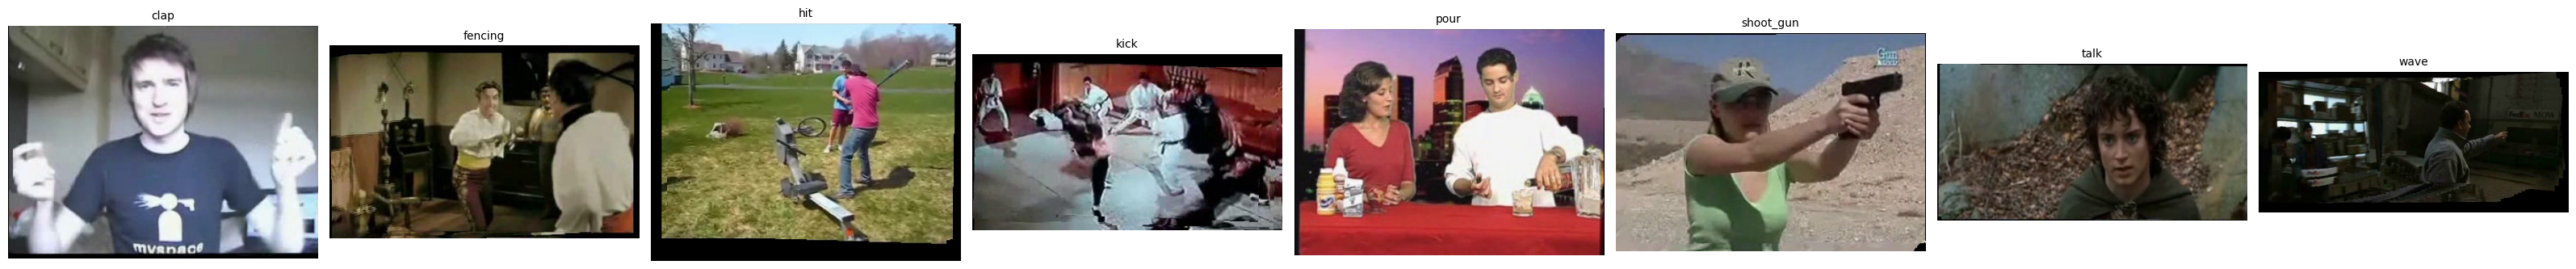

In [ ]:
classes_with_readable_video = [
    name for name in sorted_class_names if readable_paths_by_class.get(name)
]

num_to_show = min(FRAME_VISUALIZATION_NUM_CLASSES, len(classes_with_readable_video))
visualization_classes = random.sample(classes_with_readable_video, num_to_show) if num_to_show else []
visualization_classes = sorted(visualization_classes)

fig, axes = plt.subplots(1, max(num_to_show, 1), figsize=(4 * max(num_to_show, 1), 4))
if num_to_show == 1:
    axes = [axes]

for ax, class_name in zip(axes, visualization_classes):
    candidate_path = random.choice(readable_paths_by_class[class_name])
    frame = extract_middle_frame(candidate_path)
    if frame is not None:
        ax.imshow(frame)
    ax.set_title(class_name, fontsize=10)
    ax.axis("off")

if not visualization_classes:
    print("No readable videos available to visualize.")
else:
    plt.tight_layout()
    plt.show()


## 14. Save Class Mapping

Save the deterministic `class_name -> class_id` mapping to
`training/configs/action_classes.json` so Notebook 02 and the action-recognition training
notebook can load the exact same label space.


In [ ]:
CONFIGS_DIR.mkdir(parents=True, exist_ok=True)

with open(CLASS_MAPPING_PATH, "w") as f:
    json.dump(id_to_class, f, indent=2, sort_keys=True)

print(f"Saved class mapping ({len(id_to_class)} classes) to:")
print(" ", CLASS_MAPPING_PATH)


Saved class mapping (51 classes) to:
  /content/drive/MyDrive/SIH26174/training/configs/action_classes.json


## 15. Save Dataset Summary

Assemble a machine-readable summary of everything inspected in this notebook and save it to
`training/reports/dataset_summary.json`. A human-readable Markdown version is also written to
`training/reports/dataset_summary.md`.


In [ ]:
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

dataset_summary = {
    "dataset_name": "HMDB51",
    "dataset_root": str(DATASET_ROOT),
    "num_classes": len(class_dirs),
    "class_names": sorted_class_names,
    "total_video_count": total_video_count,
    "readable_video_count": readable_count,
    "unreadable_video_count": len(unreadable_videos),
    "unreadable_videos": [
        {"path": path_str, "reason": reason} for path_str, reason in unreadable_videos
    ],
    "videos_per_class": {
        row["class_name"]: int(row["video_count"])
        for _, row in videos_per_class_df.iterrows()
    },
    "detected_video_extensions": dict(all_extensions_seen),
    "anomalies": {
        "empty_classes": empty_classes,
        "unexpected_files_by_class": unexpected_files_by_class,
        "unexpected_subdirs_by_class": unexpected_subdirs_by_class,
        "root_level_unexpected_items": root_level_unexpected_items,
    },
    "metadata_sample": {
        "num_videos_sampled": len(metadata_df),
        "samples_per_class_target": METADATA_SAMPLES_PER_CLASS,
        "max_samples_cap": MAX_METADATA_SAMPLES,
        "summary_stats": (
            metadata_df[["frame_count", "fps", "duration_sec", "width", "height"]]
            .describe()
            .to_dict()
            if not metadata_df.empty else {}
        ),
        "records": metadata_df.to_dict(orient="records") if not metadata_df.empty else [],
    },
    "class_mapping_file": str(CLASS_MAPPING_PATH),
    "random_seed": RANDOM_SEED,
    "notes": (
        "HMDB51 is a general action-recognition dataset used here as a pretraining/baseline "
        "source. It is not a laboratory-experiment dataset and does not define SIH-specific "
        "experiment steps. No train/validation/test split is created in this notebook."
    ),
}

with open(DATASET_SUMMARY_JSON_PATH, "w") as f:
    json.dump(dataset_summary, f, indent=2, sort_keys=False, default=str)

print("Saved dataset summary JSON to:")
print(" ", DATASET_SUMMARY_JSON_PATH)


Saved dataset summary JSON to:
  /content/drive/MyDrive/SIH26174/training/reports/dataset_summary.json


In [ ]:
md_lines = []
md_lines.append("# HMDB51 Dataset Summary\n")
md_lines.append(f"- **Dataset root:** `{DATASET_ROOT}`\n")
md_lines.append(f"- **Total classes:** {len(class_dirs)}\n")
md_lines.append(f"- **Total videos:** {total_video_count}\n")
md_lines.append(f"- **Readable videos:** {readable_count}\n")
md_lines.append(f"- **Unreadable videos:** {len(unreadable_videos)}\n")
md_lines.append(f"- **Empty class folders:** {len(empty_classes)}\n")
md_lines.append(f"- **Detected video extensions:** {dict(all_extensions_seen)}\n")
md_lines.append("\n## Videos per class\n\n")
md_lines.append("| class_id | class_name | video_count |\n")
md_lines.append("|---|---|---|\n")
for name in sorted_class_names:
    cid = class_to_id[name]
    count = int(videos_per_class_df.loc[videos_per_class_df["class_name"] == name, "video_count"].iloc[0])
    md_lines.append(f"| {cid} | {name} | {count} |\n")

if unreadable_videos:
    md_lines.append("\n## Unreadable videos\n\n")
    for path_str, reason in unreadable_videos:
        md_lines.append(f"- `{path_str}` — {reason}\n")

with open(DATASET_SUMMARY_MD_PATH, "w") as f:
    f.writelines(md_lines)

print("Saved dataset summary Markdown to:")
print(" ", DATASET_SUMMARY_MD_PATH)


Saved dataset summary Markdown to:
  /content/drive/MyDrive/SIH26174/training/reports/dataset_summary.md


## 16. Final Summary

Consolidated output confirming the dataset contract that later notebooks (preprocessing, action
recognition training, evaluation, export) will rely on.


In [ ]:
# Verify all files were saved
print("\nVERIFYING OUTPUT FILES:")
files_to_check = [
    (CLASS_MAPPING_PATH, "Class mapping (action_classes.json)"),
    (DATASET_SUMMARY_JSON_PATH, "Dataset summary JSON"),
    (DATASET_SUMMARY_MD_PATH, "Dataset summary Markdown"),
]

for file_path, file_desc in files_to_check:
    if file_path.exists():
        file_size = file_path.stat().st_size
        print(f"  ✓ {file_desc}: {file_path} ({file_size} bytes)")
    else:
        print(f"  ❌ {file_desc}: {file_path} NOT FOUND")

print()
print("=" * 70)
print("NOTEBOOK 01 — DATASET INSPECTION — FINAL SUMMARY")
print("=" * 70)
print(f"1. Dataset root            : {DATASET_ROOT}")
print(f"2. Number of classes       : {len(class_dirs)}")
print(f"3. Total videos            : {total_video_count}")
print(f"4. Valid/readable videos   : {readable_count}")
print(f"5. Problematic videos      : {len(unreadable_videos)}")
print("6. Videos per class        : see 'videos_per_class_df' above / dataset_summary.json")
print()
print("GENERATED FILES:")
print(f"  [1] {CLASS_MAPPING_PATH}")
print(f"  [2] {DATASET_SUMMARY_JSON_PATH}")
print(f"  [3] {DATASET_SUMMARY_MD_PATH}")
print()
print("These files are required by Notebook 04 (pose/hand testing).")
print("=" * 70)
print("Dataset inspection complete.")
print("No model training, preprocessing, or splitting in this notebook.")



VERIFYING OUTPUT FILES:
  ✓ Class mapping (action_classes.json): /content/drive/MyDrive/SIH26174/training/configs/action_classes.json (930 bytes)
  ✓ Dataset summary JSON: /content/drive/MyDrive/SIH26174/training/reports/dataset_summary.json (1011235 bytes)
  ✓ Dataset summary Markdown: /content/drive/MyDrive/SIH26174/training/reports/dataset_summary.md (1497 bytes)

NOTEBOOK 01 — DATASET INSPECTION — FINAL SUMMARY
1. Dataset root            : /content/drive/MyDrive/SIH26174/training/data/raw/hmdb51_sta
2. Number of classes       : 51
3. Total videos            : 6766
4. Valid/readable videos   : 6766
5. Problematic videos      : 0
6. Videos per class        : see 'videos_per_class_df' above / dataset_summary.json

GENERATED FILES:
  [1] /content/drive/MyDrive/SIH26174/training/configs/action_classes.json
  [2] /content/drive/MyDrive/SIH26174/training/reports/dataset_summary.json
  [3] /content/drive/MyDrive/SIH26174/training/reports/dataset_summary.md

These files are required by Not

In [ ]:
# Check if files were created
from pathlib import Path

TRAINING_ROOT = Path("/content/drive/MyDrive/SIH26174/training")
CONFIGS_DIR = TRAINING_ROOT / "configs"
REPORTS_DIR = TRAINING_ROOT / "reports"

CLASS_MAPPING_PATH = CONFIGS_DIR / "action_classes.json"
DATASET_SUMMARY_JSON = REPORTS_DIR / "dataset_summary.json"
DATASET_SUMMARY_MD = REPORTS_DIR / "dataset_summary.md"

print("Checking output files:\n")
print(f"CONFIGS_DIR exists: {CONFIGS_DIR.exists()}")
print(f"REPORTS_DIR exists: {REPORTS_DIR.exists()}")
print()
print(f"action_classes.json exists: {CLASS_MAPPING_PATH.exists()}")
print(f"dataset_summary.json exists: {DATASET_SUMMARY_JSON.exists()}")
print(f"dataset_summary.md exists: {DATASET_SUMMARY_MD.exists()}")
print()

# List what's actually in those directories
if CONFIGS_DIR.exists():
    print(f"Files in {CONFIGS_DIR}:")
    for f in CONFIGS_DIR.iterdir():
        print(f"  - {f.name}")
else:
    print(f"❌ {CONFIGS_DIR} does NOT exist")

if REPORTS_DIR.exists():
    print(f"\nFiles in {REPORTS_DIR}:")
    for f in REPORTS_DIR.iterdir():
        print(f"  - {f.name}")
else:
    print(f"❌ {REPORTS_DIR} does NOT exist")

Checking output files:

CONFIGS_DIR exists: True
REPORTS_DIR exists: True

action_classes.json exists: True
dataset_summary.json exists: True
dataset_summary.md exists: True

Files in /content/drive/MyDrive/SIH26174/training/configs:
  - dataset_config.yaml
  - dataset_config.json
  - action_classes.json

Files in /content/drive/MyDrive/SIH26174/training/reports:
  - yolov8_detection_test.json
  - yolov8_detection_test.md
  - dataset_metadata.json
  - training_curves.png
  - notebook_05_part2_continuous_inference
  - action_validation_confusion_matrix.png
  - action_training_summary.json
  - action_training_history.json
  - notebook_06_integration_export
  - yolo_object_detection_examples.png
  - yolo_object_detection_test.json
  - yolo_object_detection_test.md
  - pose_hand_sampled_frames.csv
  - pose_hand_test.json
  - pose_hand_test.md
  - dataset_summary.json
  - dataset_summary.md
